In [12]:
import cv2
import numpy as np

# 1. Load the image in grayscale
img = cv2.imread("img.jpg", cv2.IMREAD_GRAYSCALE)

# 2. Initialize the SIFT detector
# Note: In OpenCV 4.4+, SIFT is in the main repository (patent expired)
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors
keypoints, descriptors = sift.detectAndCompute(img, None)

# 4. Extract values for the first keypoint descriptor
if descriptors is not None and len(descriptors) > 0:
    first_descriptor = descriptors[0]
    second_decriptor = descriptors[1]
    print(f"Total Keypoints: {len(keypoints)}")
    print(f"Descriptor Shape: {first_descriptor.shape}")  # Should be (128,)
    print(f"128 values of the first descriptor: {first_descriptor[:128]}")
    print(f"128 values of the second decriptor: {second_decriptor[:128]}")
else:
    print("No descriptors found.")

Total Keypoints: 1534
Descriptor Shape: (128,)
128 values of the first descriptor: [ 28.  44.   3.   0.   5.   8.   0.   1. 192.   9.   2.   0.   3.   1.
   0.  57. 136.  14.   1.   7.  43.   3.   1.  28.  17.  17.   3.  13.
  16.   0.   0.   0.  46.  38.   4.   1.  41.  38.   0.   1. 192.  35.
   2.   4.  14.   1.   0.  48. 124.  25.   7.  48. 102.   1.   0.  17.
  15.  24.   4.   6.   4.   0.   0.   0.  50.   6.   1.   1.  77.  75.
   4.   5. 192.  66.   1.   6.  19.  12.   3.  13.  80.  30.   4.  34.
  79.   8.   0.   1.   1.   4.   2.   2.   2.   0.   0.   0.  20.   4.
   4.   9.  86.  34.   3.   9. 192.  42.   1.   0.   4.   6.   3.  22.
  26.  14.   0.   0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.]
128 values of the second decriptor: [ 16.   5.   2.   0.   0.   0.   0.   2. 148.   2.   0.   0.   0.   1.
   1.  60. 112.   2.   2.  11.   4.   6.   8.  54.  19.   2.   2. 148.
  61.   0.   0.   3.  27.  34.   8.   0.   0.   1.   0.   3. 148.  41.
  11.  10.   1.  

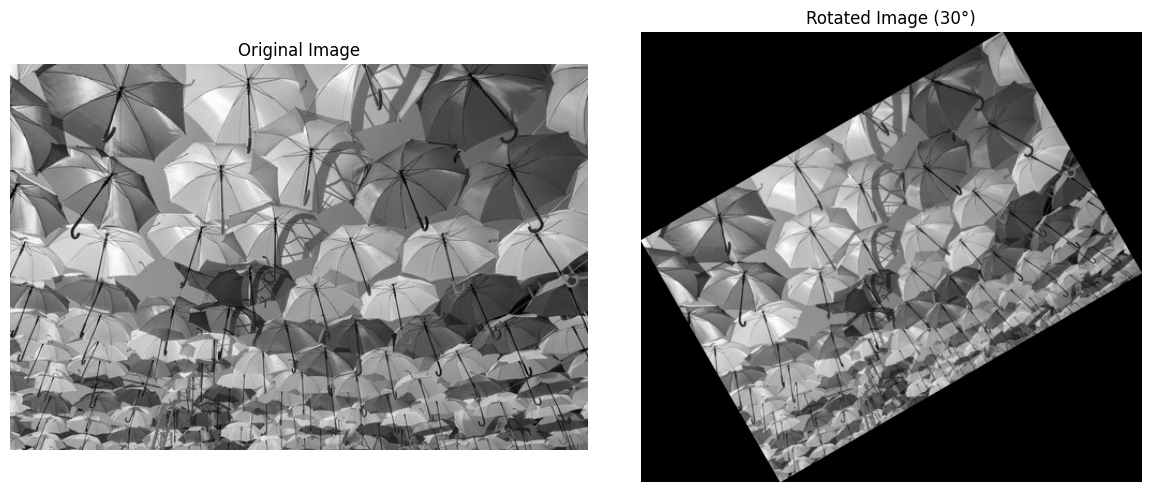

In [13]:
# Rotate image by a custom angle (no crop) and save as image2.jpg
angle = 30  # change this to any angle you want

h, w = img.shape[:2]
center = (w / 2, h / 2)

rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

# Compute new bounding dimensions to avoid cropping
cos = abs(rotation_matrix[0, 0])
sin = abs(rotation_matrix[0, 1])
new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))

# Adjust translation so the full rotated image fits
rotation_matrix[0, 2] += (new_w / 2) - center[0]
rotation_matrix[1, 2] += (new_h / 2) - center[1]

rotated_img = cv2.warpAffine(img, rotation_matrix, (new_w, new_h))
cv2.imwrite("image2.jpg", rotated_img)

import matplotlib.pyplot as plt
# Display original and rotated images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Rotated Image ({angle}°)")
plt.imshow(rotated_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:

# 1. Load the image in grayscale
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

# 2. Initialize the SIFT detector
# Note: In OpenCV 4.4+, SIFT is in the main repository (patent expired)
sift2 = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors
keypoints2, descriptors2 = sift2.detectAndCompute(img2, None)

# 4. Extract values for the first keypoint descriptor
if descriptors2 is not None and len(descriptors2) > 0:
    first_descriptor2 = descriptors2[0]
    second_decriptor2 = descriptors2[1]
    print(f"Total Keypoints: {len(keypoints2)}")
    print(f"Descriptor Shape: {first_descriptor2.shape}")  # Should be (128,)
    print(f"128 values of the first descriptor: {first_descriptor2[:128]}")
    print(f"128 values of the second decriptor: {second_decriptor2[:128]}")
else:
    print("No descriptors found.")

Total Keypoints: 2014
Descriptor Shape: (128,)
128 values of the first descriptor: [  0.   0.   0.   0.   0.   0.  42.  61.   6.   0.   0.   0.   0.   0.
  95. 143. 131.   0.   0.   0.   0.   0.  28. 149.  54.   3.   4.   2.
   0.   0.  35. 149.   2.   1.   8.  10.   1.   0.  81. 149.  48.   7.
   9.  24.   3.   2.  63.  68. 149.  14.   2.   1.   0.   0.   5.  74.
  83.  18.  29.  28.   0.   0.   0.  11.   2.   2.  19.  18.   7.   3.
   3.  14.  66.  18.  10.  26.   3.   0.   0.   1. 149. 111.  21.   3.
   0.   0.   0.   3.  28.  35.  75.  63.   0.   0.   4.   7.   0.   0.
   0.   6.  19.   2.   0.   0.  36.   7.   1.   4.  10.   1.   1.  30.
 103.  45.   5.   0.   0.   0.   1. 108.  25.  16.  10.   4.   0.   0.
   6.  43.]
128 values of the second decriptor: [  0.   0.   0.   0.   0.   0.   0.   0. 111.  32.   0.   0.   0.   0.
   0.   0. 156. 156.  46.   2.   0.   0.   0.   0.   4. 156.  98.   7.
   2.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0. 132.   9.
   0.   0.   0.  

In [ ]:

sift_match = cv2.SIFT_create()
keypoints1, descriptors1 = sift_match.detectAndCompute(img, None)
keypoints2, descriptors2 = sift_match.detectAndCompute(img2, None)

if descriptors1 is None or descriptors2 is None or len(descriptors1) == 0 or len(descriptors2) == 0:
    print("Not enough descriptors to compare.")
else:
    descriptors1 = descriptors1.astype(np.float32)
    descriptors2 = descriptors2.astype(np.float32)

    min_distances = np.empty(len(descriptors1), dtype=np.float32)

    for idx, d1 in enumerate(descriptors1):
        diff = descriptors2 - d1                
        sq_distances = np.sum(diff * diff, axis=1)
        min_distances[idx] = np.sqrt(np.min(sq_distances))

    print("Computed minimum distance for each descriptor in img1 -> img2")
    print(f"Total descriptors in img1: {len(descriptors1)}")
    print(f"Total min distances computed: {len(min_distances)}")
    print("First 20 min distances:")
    print(min_distances[:20])

Computed minimum distance for each descriptor in img1 -> img2
Total descriptors in img1: 2014
Total min distances computed: 2014
First 20 min distances:
[  6.8556547 244.48517    64.218376    6.244998    4.690416    3.7416575
 100.159874    6.4807405  10.099504   12.0415945 199.91248     5.0990195
   3.7416575 293.21835     2.236068   20.566963  122.376465    5.2915025
   5.477226    2.       ]
